# Módulo 2 — NSGA-II Multiobjetivo para Optimización de Portafolio## Proyecto Semana 14 · ADA · UNMSM**Algoritmo:** NSGA-II (Non-dominated Sorting Genetic Algorithm II) con DEAP**Referencia:** Deb, K. et al. (2002). IEEE Trans. Evol. Computation, 6(2), 182-197.**Inspirado en:** Eq3 Notebook C + Eq5 Notebook C (NSGA-II)

In [11]:
!pip install deap yfinance --quiet

In [12]:
# ═══════════════════════════════════════════════════════════════
# CONFIGURACIÓN Y CARGA DE DATOS
# ═══════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import yfinance as yf
import random
import json
import matplotlib.pyplot as plt
from deap import base, creator, tools, algorithms
from scipy.optimize import minimize
import warnings

warnings.filterwarnings('ignore')

TICKERS = ['FSM', 'VOLCABC1.LM', 'ABX.TO', 'BVN', 'BHP']
FECHA_INICIO, FECHA_FIN = '2015-01-01', '2024-12-31'
CAPITAL, DIAS_ANIO, RF = 100_000, 252, 0.02
MU_POP, NGEN = 100, 80

# Población y generaciones NSGA-II
SEMILLA = 42
random.seed(SEMILLA)
np.random.seed(SEMILLA)

datos = yf.download(TICKERS, start=FECHA_INICIO, end=FECHA_FIN, auto_adjust=True, progress=False)
precios = datos['Close'].dropna(how='all').dropna()

if isinstance(precios.columns, pd.MultiIndex):
    precios.columns = precios.columns.get_level_values(0)

retornos = np.log(precios / precios.shift(1)).dropna()
mu_vec = retornos.mean().values * DIAS_ANIO
Sigma = retornos.cov().values * DIAS_ANIO
N = len(TICKERS)

print(f"Datos cargados: {N} activos, {len(retornos)} días")

Datos cargados: 5 activos, 2453 días


## 1. Configuración NSGA-II con DEAP

In [13]:
# Fitness bi-objetivo: MINIMIZAR (-retorno, riesgo)

if hasattr(creator, 'FitnessMO'):
    del creator.FitnessMO
if hasattr(creator, 'Individual'):
    del creator.Individual

creator.create('FitnessMO', base.Fitness, weights=(-1.0, -1.0))  # minimizar ambos
creator.create('Individual', list, fitness=creator.FitnessMO)

def decodificar(ind):
    w = np.clip(np.array(ind, dtype=float), 0, None)
    s = w.sum()
    return w / s if s > 1e-10 else np.ones(N) / N

def evaluar(ind):
    w = decodificar(ind)
    ret = w @ mu_vec
    vol = np.sqrt(w @ Sigma @ w)
    return (-ret, vol)  # minimizar -retorno y volatilidad

tb = base.Toolbox()
tb.register('attr_float', random.random)
tb.register('individual', tools.initRepeat, creator.Individual, tb.attr_float, n=N)
tb.register('population', tools.initRepeat, list, tb.individual)
tb.register('evaluate', evaluar)
tb.register('mate', tools.cxSimulatedBinaryBounded, low=0, up=1, eta=20)
tb.register('mutate', tools.mutPolynomialBounded, low=0, up=1, eta=20, indpb=1.0/N)
tb.register('select', tools.selNSGA2)

print(f"NSGA-II configurado: MU={MU_POP}, NGEN={NGEN}, N={N} activos")

NSGA-II configurado: MU=100, NGEN=80, N=5 activos


## 2. Ciclo evolutivo NSGA-II

In [14]:
# Inicializar población
pop = tb.population(n=MU_POP)
for ind in pop:
    ind.fitness.values = tb.evaluate(ind)
pop = tb.select(pop, MU_POP)

# Evolución
CXPB, MUTPB = 0.9, 0.2
hv_historia = []

for gen in range(NGEN):
    offspring = tools.selTournamentDCD(pop, len(pop))
    offspring = [tb.clone(ind) for ind in offspring]

    for i in range(0, len(offspring) - 1, 2):
        if random.random() < CXPB:
            tb.mate(offspring[i], offspring[i+1])
            del offspring[i].fitness.values, offspring[i+1].fitness.values

    for ind in offspring:
        if random.random() < MUTPB:
            tb.mutate(ind)
            del ind.fitness.values

    invalids = [ind for ind in offspring if not ind.fitness.valid]
    for ind in invalids:
        ind.fitness.values = tb.evaluate(ind)

    pop = tb.select(pop + offspring, MU_POP)

    if gen % 20 == 0:
        frente = tools.sortNondominated(pop, len(pop), first_front_only=True)[0]
        print(f"  Gen {gen:3d}: frente Pareto = {len(frente)} individuos")

# Extraer frente final
frente_final = tools.sortNondominated(pop, len(pop), first_front_only=True)[0]
pts = np.array([ind.fitness.values for ind in frente_final])
pts[:, 0] *= -1  # convertir -retorno a retorno

print(f"\nFrente Pareto final: {len(frente_final)} portafolios no-dominados")

  Gen   0: frente Pareto = 5 individuos
  Gen  20: frente Pareto = 32 individuos
  Gen  40: frente Pareto = 100 individuos
  Gen  60: frente Pareto = 100 individuos

Frente Pareto final: 100 portafolios no-dominados


## 3. Frontera de Markowitz analítica (referencia)

In [15]:
def min_var_ret(objetivo):
    cons = [{'type':'eq','fun':lambda w:w.sum()-1}, {'type':'eq','fun':lambda w:w@mu_vec-objetivo}]
    r = minimize(lambda w:np.sqrt(w@Sigma@w), np.ones(N)/N, method='SLSQP',
                 bounds=[(0,1)]*N, constraints=cons)
    return np.sqrt(r.x@Sigma@r.x) if r.success else np.nan

rets_mk = np.linspace(mu_vec.min(), mu_vec.max(), 200)
vols_mk = np.array([min_var_ret(r) for r in rets_mk])

## 4. Visualización: Frente Pareto vs Frontera de Markowitz

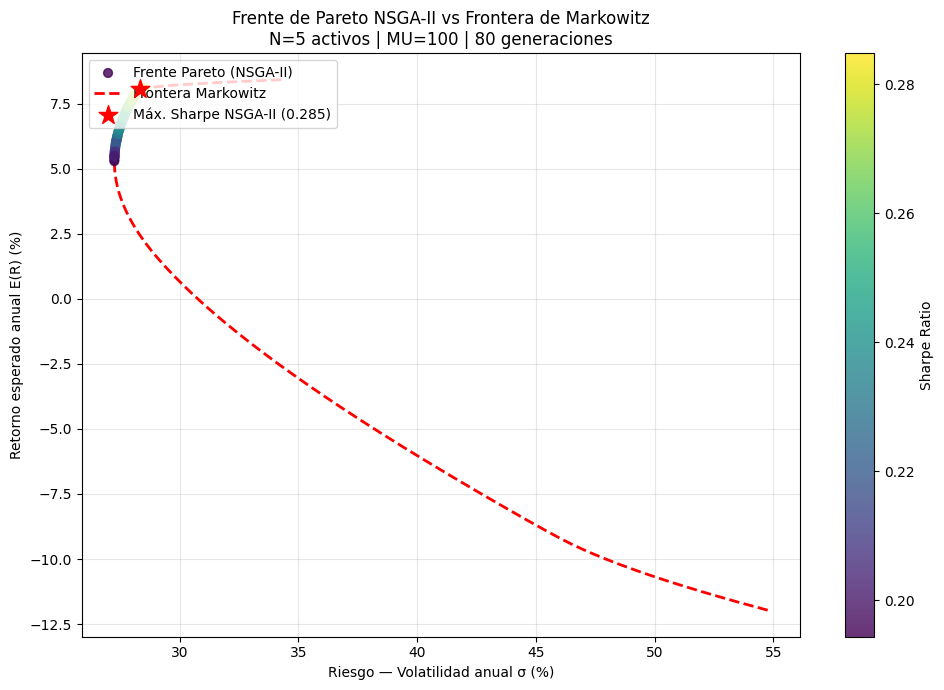

In [16]:
sharpe_frente = pts[:, 0] / pts[:, 1]
idx_best = int(np.argmax(sharpe_frente))

fig, ax = plt.subplots(figsize=(10, 7))

sc = ax.scatter(pts[:, 1]*100, pts[:, 0]*100, c=sharpe_frente, cmap='viridis',
                s=40, alpha=0.8, zorder=5, label='Frente Pareto (NSGA-II)')

mask = ~np.isnan(vols_mk)
ax.plot(vols_mk[mask]*100, rets_mk[mask]*100, 'r--', lw=2, label='Frontera Markowitz')
ax.scatter(pts[idx_best, 1]*100, pts[idx_best, 0]*100, c='red', s=200,
           marker='*', zorder=10, label=f'Máx. Sharpe NSGA-II ({sharpe_frente[idx_best]:.3f})')

ax.set_xlabel('Riesgo — Volatilidad anual σ (%)')
ax.set_ylabel('Retorno esperado anual E(R) (%)')
ax.set_title(f'Frente de Pareto NSGA-II vs Frontera de Markowitz\nN={N} activos | MU={MU_POP} | {NGEN} generaciones')
ax.legend(loc='upper left')
plt.colorbar(sc, ax=ax, label='Sharpe Ratio')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Portafolios representativos del frente Pareto

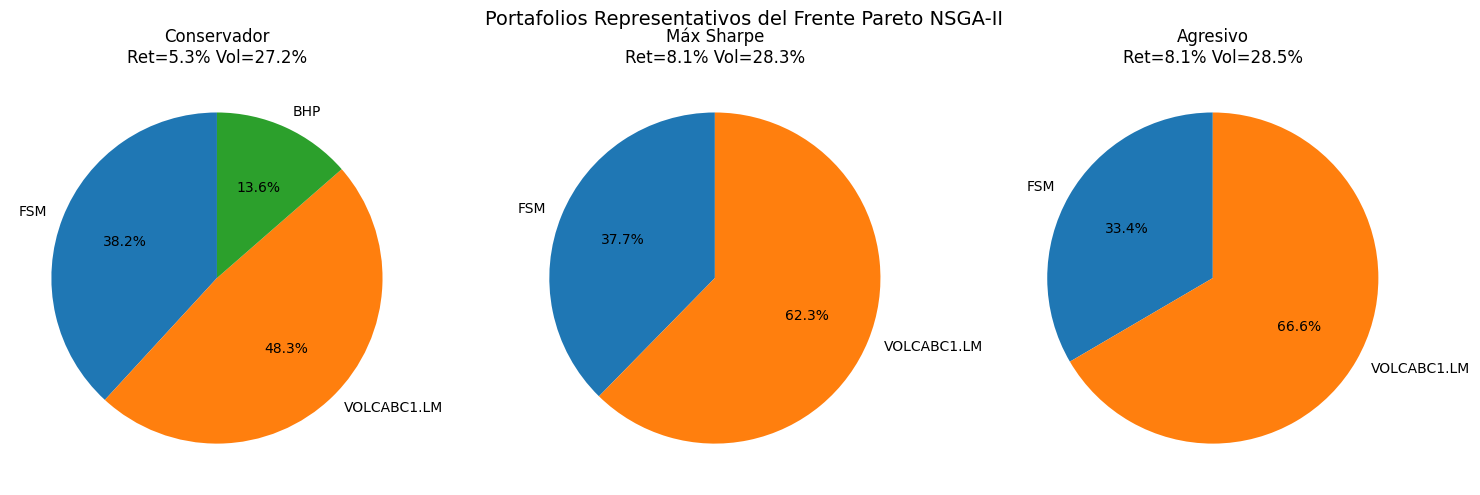


Conservador: Ret=5.30% Vol=27.25% Sharpe=0.194
  FSM             → 38.2%
  VOLCABC1.LM     → 48.3%
  BHP             → 13.6%

Máx Sharpe: Ret=8.07% Vol=28.33% Sharpe=0.285
  FSM             → 37.7%
  VOLCABC1.LM     → 62.3%

Agresivo: Ret=8.11% Vol=28.55% Sharpe=0.284
  FSM             → 33.4%
  VOLCABC1.LM     → 66.6%


In [17]:
i_cons = int(np.argmin(pts[:, 1]))  # Mín riesgo
i_agr  = int(np.argmax(pts[:, 0]))  # Máx retorno

perfiles = {'Conservador': i_cons, 'Máx Sharpe': idx_best, 'Agresivo': i_agr}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (nombre, idx) in zip(axes, perfiles.items()):
    w = decodificar(frente_final[idx])
    mask = w > 0.01
    labels = [t for t, m in zip(TICKERS, mask) if m]
    sizes = [v for v, m in zip(w, mask) if m]
    ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
    ret_p, vol_p = pts[idx]
    ax.set_title(f'{nombre}\nRet={ret_p*100:.1f}% Vol={vol_p*100:.1f}%')

plt.suptitle('Portafolios Representativos del Frente Pareto NSGA-II', fontsize=14)
plt.tight_layout()
plt.show()

for nombre, idx in perfiles.items():
    w = decodificar(frente_final[idx])
    print(f"\n{nombre}: Ret={pts[idx,0]*100:.2f}% Vol={pts[idx,1]*100:.2f}% Sharpe={pts[idx,0]/pts[idx,1]:.3f}")
    for t, wi in zip(TICKERS, w):
        if wi > 0.01: print(f"  {t:15s} → {wi*100:.1f}%")

## 6. Simulación de riqueza: GA Rebalanceado vs Buy & Hold

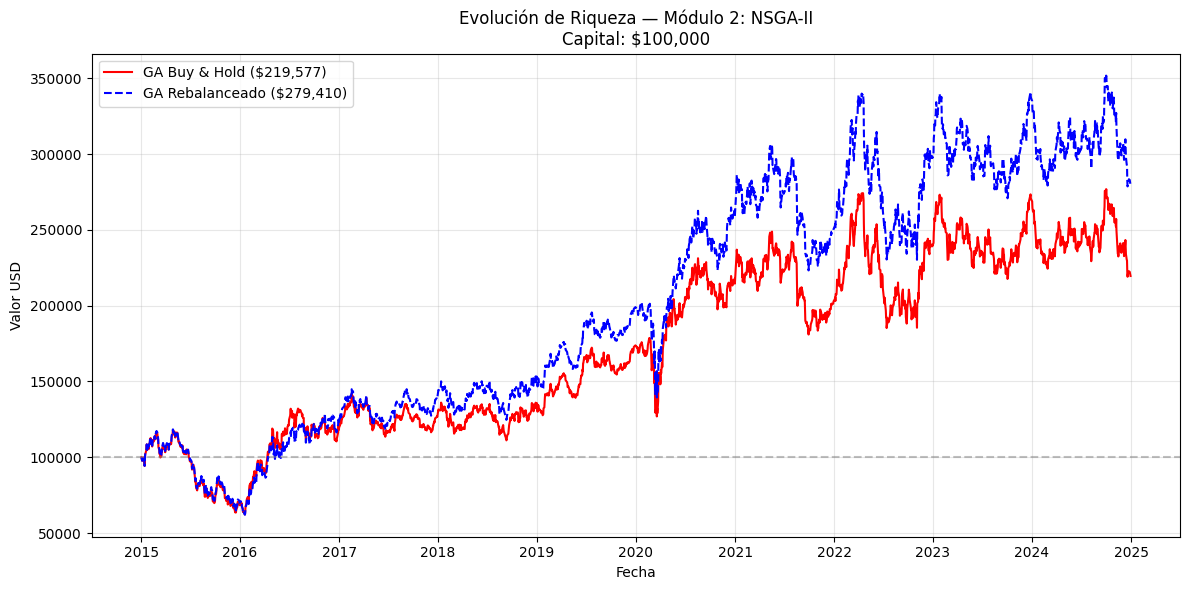

Resultados guardados en resultados_m2.json


In [18]:
ret_simples = precios.pct_change().dropna()
w_ga = decodificar(frente_final[idx_best])  # Pesos del mejor Sharpe

# GA Buy & Hold
riqueza_ga_bh = [CAPITAL]
w_t = w_ga.copy()

for i in range(len(ret_simples)):
    r = ret_simples.iloc[i].values
    riqueza_ga_bh.append(riqueza_ga_bh[-1] * (1 + w_t @ r))
    w_t = w_t * (1 + r)
    w_t /= w_t.sum()

# GA Rebalanceado mensual
riqueza_ga_reb = [CAPITAL]
w_t = w_ga.copy()
ult_mes = ret_simples.index[0].month

for i in range(len(ret_simples)):
    r = ret_simples.iloc[i].values
    riqueza_ga_reb.append(riqueza_ga_reb[-1] * (1 + w_t @ r))

    if ret_simples.index[i].month != ult_mes:
        w_t = w_ga.copy()
        ult_mes = ret_simples.index[i].month
    else:
        w_t = w_t * (1 + r)
        w_t /= w_t.sum()

fechas = [precios.index[0]] + list(ret_simples.index)
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(fechas, riqueza_ga_bh, 'r-', lw=1.5, label=f'GA Buy & Hold (${riqueza_ga_bh[-1]:,.0f})')
ax.plot(fechas, riqueza_ga_reb, 'b--', lw=1.5, label=f'GA Rebalanceado (${riqueza_ga_reb[-1]:,.0f})')
ax.axhline(y=CAPITAL, color='gray', ls='--', alpha=0.5)
ax.set_title(f'Evolución de Riqueza — Módulo 2: NSGA-II\nCapital: ${CAPITAL:,.0f}')
ax.set_xlabel('Fecha')
ax.set_ylabel('Valor USD')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Guardar resultados
resultados_m2 = {
    'riqueza_ga_bh': float(riqueza_ga_bh[-1]),
    'riqueza_ga_reb': float(riqueza_ga_reb[-1]),
    'w_ga': w_ga.tolist(),
    'sharpe_ga': float(sharpe_frente[idx_best])
}

with open('resultados_m2.json', 'w') as f:
    json.dump(resultados_m2, f, indent=2)

print("Resultados guardados en resultados_m2.json")